In [1]:
# Question 3: Homography-based Image Overlay

This notebook implements a complete pipeline for overlaying one image onto another using homography transformations. The implementation includes:

1. **Homography Computation**: Computing the transformation matrix from point correspondences
2. **Image Warping**: Transforming the overlay image using the computed homography
3. **Interactive Point Selection**: GUI for selecting corresponding points
4. **Image Blending**: Combining the warped overlay with the background image

## Key Features:
- Custom homography computation algorithm
- Custom image warping with bilinear interpolation
- Interactive point selection interface
- Comparison with OpenCV's built-in functions
- Real-time visualization of results

SyntaxError: unterminated string literal (detected at line 14) (20181160.py, line 14)

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ==================== HOMOGRAPHY COMPUTATION ====================
def compute_homography(src_points, dst_points):
    """
    Compute homography matrix H from 4 point correspondences
    Maps src_points to dst_points: dst = H @ src
    
    Parameters:
    -----------
    src_points : np.array (4, 2)
        Four points in source image [x, y]
    dst_points : np.array (4, 2)
        Four corresponding points in destination image [x, y]
    
    Returns:
    --------
    H : np.array (3, 3)
        Homography matrix
    """
    # Need at least 4 point correspondences
    assert src_points.shape[0] >= 4 and dst_points.shape[0] >= 4
    
    # Build matrix A for linear system Ah = 0
    # For each point correspondence (x, y) -> (x', y'), we get 2 equations:
    # -x  -y  -1   0   0   0  x*x'  y*x'  x'
    #  0   0   0  -x  -y  -1  x*y'  y*y'  y'
    
    A = []
    for i in range(4):
        x, y = src_points[i]
        xp, yp = dst_points[i]
        
        # First equation (for x')
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        # Second equation (for y')
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])
    
    A = np.array(A)
    
    # Solve using least squares (SVD)
    # The solution h is the last column of V (or last row of V^T)
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    
    # Reshape h into 3x3 homography matrix
    H = h.reshape(3, 3)
    
    # Normalize so that H[2,2] = 1
    H = H / H[2, 2]
    
    return H

In [3]:
# ==================== IMAGE WARPING ====================
def warp_image(src_img, H, output_shape):
    """
    Warp source image using homography matrix H
    
    Parameters:
    -----------
    src_img : np.array
        Source image to warp
    H : np.array (3, 3)
        Homography matrix
    output_shape : tuple (height, width)
        Shape of output image
    
    Returns:
    --------
    warped : np.array
        Warped image
    mask : np.array
        Binary mask showing valid warped regions
    """
    h_out, w_out = output_shape
    
    # Create output image
    if len(src_img.shape) == 3:
        warped = np.zeros((h_out, w_out, src_img.shape[2]), dtype=src_img.dtype)
    else:
        warped = np.zeros((h_out, w_out), dtype=src_img.dtype)
    
    mask = np.zeros((h_out, w_out), dtype=np.uint8)
    
    # Compute inverse homography for backward warping
    H_inv = np.linalg.inv(H)
    
    # For each pixel in output image, find corresponding pixel in source
    for y_out in range(h_out):
        for x_out in range(w_out):
            # Homogeneous coordinates
            p_out = np.array([x_out, y_out, 1])
            
            # Map to source image coordinates
            p_src_h = H_inv @ p_out
            
            # Convert from homogeneous to Cartesian
            x_src = p_src_h[0] / p_src_h[2]
            y_src = p_src_h[1] / p_src_h[2]
            
            # Check if source coordinates are within bounds
            if 0 <= x_src < src_img.shape[1]-1 and 0 <= y_src < src_img.shape[0]-1:
                # Bilinear interpolation
                x0 = int(np.floor(x_src))
                x1 = x0 + 1
                y0 = int(np.floor(y_src))
                y1 = y0 + 1
                
                # Interpolation weights
                wx = x_src - x0
                wy = y_src - y0
                
                # Bilinear interpolation
                if len(src_img.shape) == 3:
                    warped[y_out, x_out] = (
                        (1-wx)*(1-wy)*src_img[y0, x0] +
                        wx*(1-wy)*src_img[y0, x1] +
                        (1-wx)*wy*src_img[y1, x0] +
                        wx*wy*src_img[y1, x1]
                    )
                else:
                    warped[y_out, x_out] = (
                        (1-wx)*(1-wy)*src_img[y0, x0] +
                        wx*(1-wy)*src_img[y0, x1] +
                        (1-wx)*wy*src_img[y1, x0] +
                        wx*wy*src_img[y1, x1]
                    )
                
                mask[y_out, x_out] = 255
    
    return warped, mask

In [4]:
# ==================== INTERACTIVE POINT SELECTION ====================
class PointSelector:
    def __init__(self, image, window_name, num_points=4):
        self.image = image.copy()
        self.window_name = window_name
        self.num_points = num_points
        self.points = []
        self.display_image = image.copy()
        
    def mouse_callback(self, event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN and len(self.points) < self.num_points:
            self.points.append([x, y])
            # Draw point
            cv2.circle(self.display_image, (x, y), 5, (0, 255, 0), -1)
            cv2.putText(self.display_image, str(len(self.points)), (x+10, y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            cv2.imshow(self.window_name, self.display_image)
            
            if len(self.points) == self.num_points:
                print(f"Selected {self.num_points} points. Press any key to continue...")
    
    def select_points(self):
        cv2.namedWindow(self.window_name)
        cv2.setMouseCallback(self.window_name, self.mouse_callback)
        cv2.imshow(self.window_name, self.display_image)
        
        print(f"Click {self.num_points} points in order (e.g., top-left, top-right, bottom-right, bottom-left)")
        cv2.waitKey(0)
        cv2.destroyWindow(self.window_name)
        
        return np.array(self.points, dtype=np.float32)

In [5]:
# ==================== BLENDING ====================
def blend_images(background, foreground, mask, alpha=0.7):
    """
    Blend foreground onto background using mask
    
    Parameters:
    -----------
    background : np.array
        Background image
    foreground : np.array
        Foreground (warped) image
    mask : np.array
        Binary mask of valid foreground pixels
    alpha : float
        Blending weight for foreground (0-1)
    
    Returns:
    --------
    blended : np.array
        Blended image
    """
    blended = background.copy()
    
    # Normalize mask to [0, 1]
    mask_norm = mask.astype(np.float32) / 255.0
    
    # Expand mask to match image channels
    if len(background.shape) == 3:
        mask_norm = np.stack([mask_norm] * background.shape[2], axis=2)
    
    # Alpha blending where mask is valid
    blended = blended.astype(np.float32)
    foreground = foreground.astype(np.float32)
    
    blended = (1 - alpha * mask_norm) * blended + alpha * mask_norm * foreground
    
    return blended.astype(np.uint8)

In [6]:
# ==================== MAIN PIPELINE ====================
def homography_image_overlay(background_path, overlay_path, use_opencv=False):
    """
    Complete pipeline for overlaying one image onto another using homography
    
    Parameters:
    -----------
    background_path : str
        Path to background/architectural image
    overlay_path : str
        Path to overlay image (e.g., flag)
    use_opencv : bool
        If True, use OpenCV's built-in functions for comparison
    """
    # Load images
    background = cv2.imread(background_path)
    overlay = cv2.imread(overlay_path)
    
    if background is None or overlay is None:
        print("Error: Could not load images!")
        return
    
    # Convert BGR to RGB for display
    background_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    
    print("="*70)
    print("STEP 1: Select 4 points in BACKGROUND image")
    print("="*70)
    print("Select points defining the planar region (e.g., corners of a rectangle)")
    print("Order: top-left, top-right, bottom-right, bottom-left")
    
    # Select points in background image
    bg_selector = PointSelector(background, "Background Image - Select 4 Points", 4)
    bg_points = bg_selector.select_points()
    
    print(f"\nBackground points:\n{bg_points}")
    
    # Define source points (corners of overlay image)
    h_overlay, w_overlay = overlay.shape[:2]
    src_points = np.float32([
        [0, 0],                    # top-left
        [w_overlay-1, 0],          # top-right
        [w_overlay-1, h_overlay-1], # bottom-right
        [0, h_overlay-1]           # bottom-left
    ])
    
    print(f"\nOverlay image corners (source points):\n{src_points}")
    
    # Compute homography
    print("\n" + "="*70)
    print("STEP 2: Computing Homography")
    print("="*70)
    
    if use_opencv:
        # Using OpenCV's built-in function
        H = cv2.getPerspectiveTransform(src_points, bg_points)
        print("Using OpenCV's getPerspectiveTransform()")
    else:
        # Using custom implementation
        H = compute_homography(src_points, bg_points)
        print("Using custom homography computation")
    
    print(f"\nHomography Matrix H:\n{H}")
    
    # Warp overlay image
    print("\n" + "="*70)
    print("STEP 3: Warping Overlay Image")
    print("="*70)
    
    output_shape = background.shape[:2]
    
    if use_opencv:
        # Using OpenCV's built-in function
        warped = cv2.warpPerspective(overlay, H, (background.shape[1], background.shape[0]))
        mask = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
        mask = (mask > 0).astype(np.uint8) * 255
        print("Using OpenCV's warpPerspective()")
    else:
        # Using custom implementation
        warped, mask = warp_image(overlay, H, output_shape)
        print("Using custom image warping")
    
    # Blend images
    print("\n" + "="*70)
    print("STEP 4: Blending Images")
    print("="*70)
    
    blended = blend_images(background, warped, mask, alpha=0.9)
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Background Image')
    axes[0, 0].axis('off')
    # Draw selected points
    for i, pt in enumerate(bg_points):
        axes[0, 0].plot(pt[0], pt[1], 'go', markersize=10)
        axes[0, 0].text(pt[0]+10, pt[1], str(i+1), color='green', fontsize=12)
    
    axes[0, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('Overlay Image (Flag)')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('Warped Overlay')
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(mask, cmap='gray')
    axes[1, 0].set_title('Warp Mask')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('Final Blended Result')
    axes[1, 1].axis('off')
    
    # Show homography matrix
    axes[1, 2].axis('off')
    axes[1, 2].text(0.1, 0.8, 'Homography Matrix H:', fontsize=12, fontweight='bold')
    h_text = '\n'.join([f"[{H[i,0]:8.4f} {H[i,1]:8.4f} {H[i,2]:8.4f}]" for i in range(3)])
    axes[1, 2].text(0.1, 0.4, h_text, fontsize=10, family='monospace')
    
    plt.tight_layout()
    plt.savefig('homography_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Save result
    cv2.imwrite('blended_result.jpg', blended)
    print("\nResults saved: homography_result.png, blended_result.jpg")
    
    return H, blended

Question 3: Homography-based Image Overlay

### Example: Flag on Building ###


Running with CUSTOM implementation
STEP 1: Select 4 points in BACKGROUND image
Select points defining the planar region (e.g., corners of a rectangle)
Order: top-left, top-right, bottom-right, bottom-left
Click 4 points in order (e.g., top-left, top-right, bottom-right, bottom-left)
Selected 4 points. Press any key to continue...
Selected 4 points. Press any key to continue...

Background points:
[[329. 176.]
 [477.  80.]
 [473. 219.]
 [320. 297.]]

Overlay image corners (source points):
[[  0.   0.]
 [317.   0.]
 [317. 158.]
 [  0. 158.]]

STEP 2: Computing Homography
Using custom homography computation

Homography Matrix H:
[[ 2.41113337e-01 -1.31093150e-01  3.29000000e+02]
 [-3.40703039e-01  6.97019835e-01  1.76000000e+02]
 [-4.73299025e-04 -2.31659765e-04  1.00000000e+00]]

STEP 3: Warping Overlay Image

Background points:
[[329. 176.]
 [477.  80.]
 [473. 219.]
 [320. 297.]]

Overlay image corners (sour

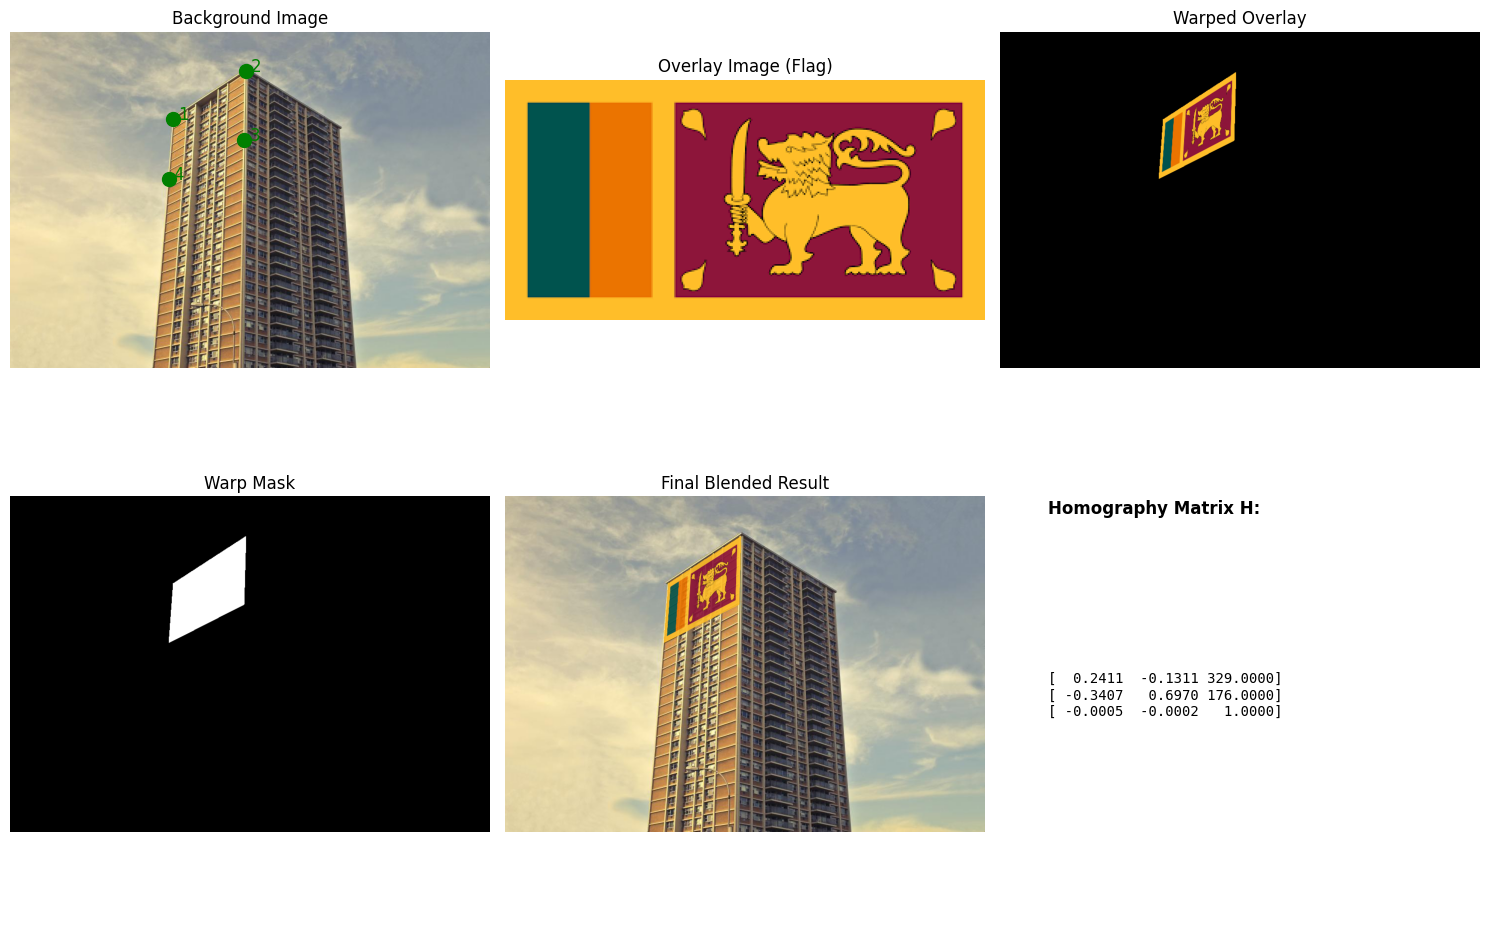


Results saved: homography_result.png, blended_result.jpg

Running with OPENCV implementation (for comparison)
STEP 1: Select 4 points in BACKGROUND image
Select points defining the planar region (e.g., corners of a rectangle)
Order: top-left, top-right, bottom-right, bottom-left
Click 4 points in order (e.g., top-left, top-right, bottom-right, bottom-left)
Selected 4 points. Press any key to continue...
Selected 4 points. Press any key to continue...

Background points:
[[329. 175.]
 [478.  82.]
 [473. 219.]
 [321. 296.]]

Overlay image corners (source points):
[[  0.   0.]
 [317.   0.]
 [317. 158.]
 [  0. 158.]]

STEP 2: Computing Homography
Using OpenCV's getPerspectiveTransform()

Homography Matrix H:
[[ 2.73568824e-01 -9.94385269e-02  3.29000000e+02]
 [-3.27078204e-01  7.20818230e-01  1.75000000e+02]
 [-4.11009879e-04 -1.52042416e-04  1.00000000e+00]]

STEP 3: Warping Overlay Image
Using OpenCV's warpPerspective()

STEP 4: Blending Images

Background points:
[[329. 175.]
 [478.  8

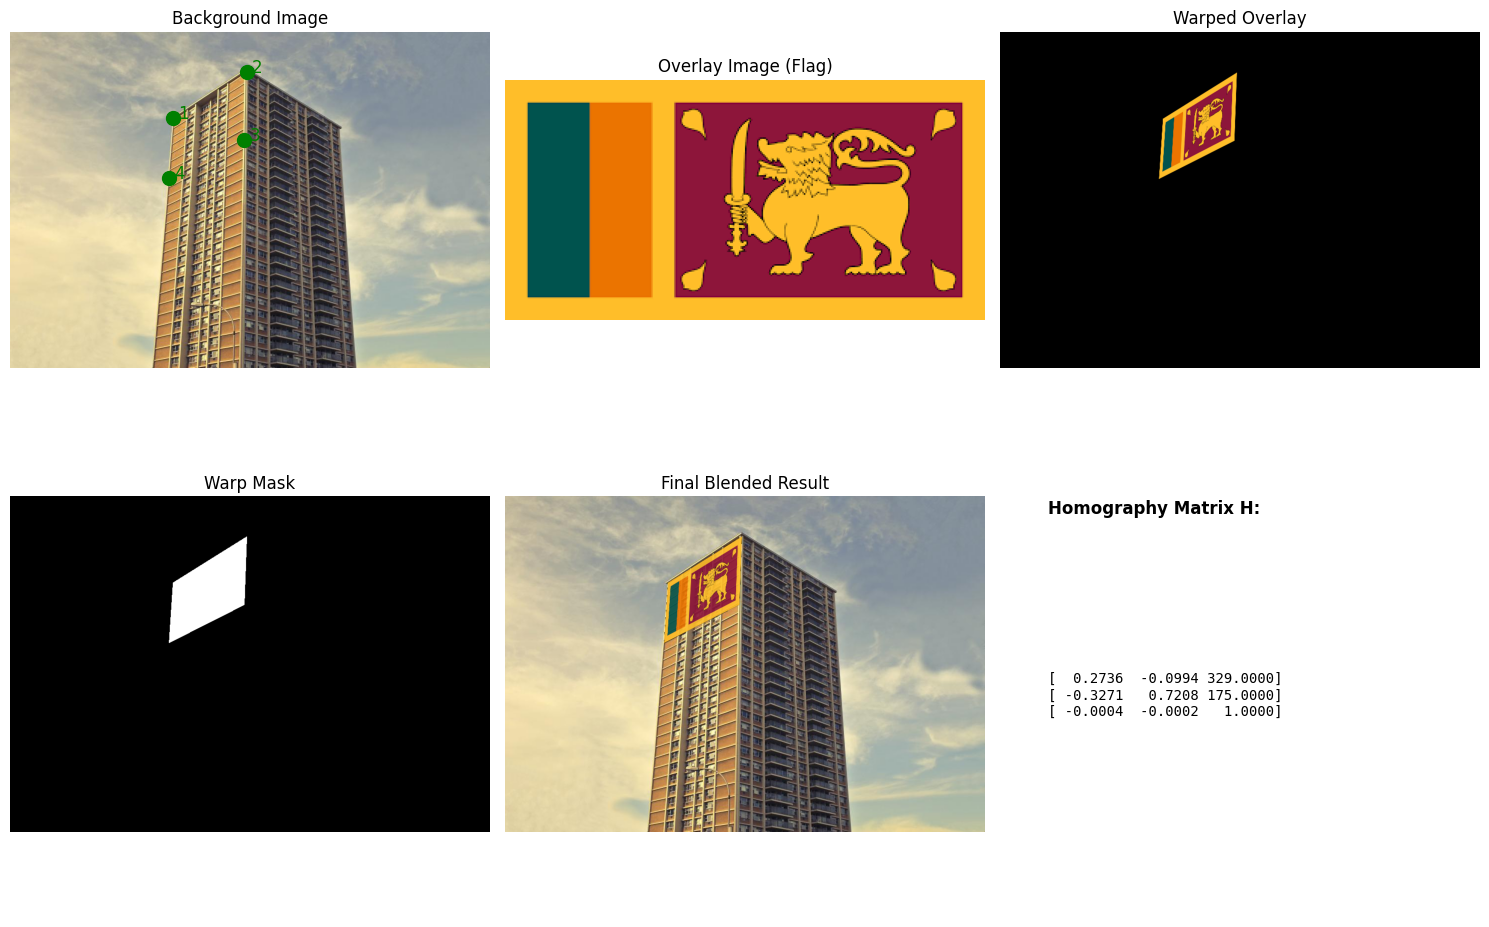


Results saved: homography_result.png, blended_result.jpg

Comparison of Homography Matrices

Custom Implementation:
[[ 2.41113337e-01 -1.31093150e-01  3.29000000e+02]
 [-3.40703039e-01  6.97019835e-01  1.76000000e+02]
 [-4.73299025e-04 -2.31659765e-04  1.00000000e+00]]

OpenCV Implementation:
[[ 2.73568824e-01 -9.94385269e-02  3.29000000e+02]
 [-3.27078204e-01  7.20818230e-01  1.75000000e+02]
 [-4.11009879e-04 -1.52042416e-04  1.00000000e+00]]

Difference:
[[3.24554870e-02 3.16546233e-02 5.68434189e-14]
 [1.36248343e-02 2.37983952e-02 1.00000000e+00]
 [6.22891462e-05 7.96173494e-05 0.00000000e+00]]
Max difference: 1.000000


In [12]:
# ==================== EXAMPLE USAGE ====================
if __name__ == "__main__":
    print("="*70)
    print("Question 3: Homography-based Image Overlay")
    print("="*70)
    
    # Example: Flag overlay on architectural image
    print("\n### Example: Flag on Building ###\n")
    
    # You need to provide your own image paths or use the ones from the Assignment folder
    background_path = r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\building.jpg'
    flag_path = r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\flag.png'
    
    # Check if files exist
    import os
    if not os.path.exists(background_path):
        print(f"Background image not found at '{background_path}'")
        print("Creating synthetic example...")
        background = np.ones((600, 800, 3), dtype=np.uint8) * 200
        cv2.rectangle(background, (200, 150), (600, 450), (150, 150, 150), -1)
        cv2.imwrite('synthetic_background.jpg', background)
        background_path = 'synthetic_background.jpg'
    
    if not os.path.exists(flag_path):
        print(f"Flag image not found at '{flag_path}'")
        print("Creating synthetic flag...")
        flag = np.zeros((300, 450, 3), dtype=np.uint8)
        flag[:100, :, :] = [255, 0, 0]      # Red
        flag[100:200, :, :] = [255, 255, 255]  # White
        flag[200:, :, :] = [0, 0, 255]      # Blue
        cv2.imwrite('synthetic_flag.jpg', flag)
        flag_path = 'synthetic_flag.jpg'
    
    # Run the pipeline with custom implementation
    print("\n" + "="*70)
    print("Running with CUSTOM implementation")
    print("="*70)
    H_custom, result_custom = homography_image_overlay(background_path, flag_path, use_opencv=False)
    
    # Run with OpenCV for comparison
    print("\n" + "="*70)
    print("Running with OPENCV implementation (for comparison)")
    print("="*70)
    H_opencv, result_opencv = homography_image_overlay(background_path, flag_path, use_opencv=True)
    
    # Compare homography matrices
    print("\n" + "="*70)
    print("Comparison of Homography Matrices")
    print("="*70)
    print(f"\nCustom Implementation:\n{H_custom}")
    print(f"\nOpenCV Implementation:\n{H_opencv}")
    print(f"\nDifference:\n{np.abs(H_custom - H_opencv)}")
    print(f"Max difference: {np.max(np.abs(H_custom - H_opencv)):.6f}")

## Alternative Implementation (OpenCV-based)
Here's a simpler approach using OpenCV's built-in functions for interactive point selection:

In [9]:
import cv2
import numpy as np

# Global variables to store clicked points
clicked_points = []

# Mouse callback function to collect four points
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
        clicked_points.append([x, y])
        cv2.circle(arch_img_display, (x, y), 5, (0, 255, 0), -1)
        cv2.imshow("Architectural Image - Click 4 points", arch_img_display)

# Load the architectural image (background)
arch_img = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\building.jpg')
arch_img_display = arch_img.copy()

# Load the flag image to be warped and overlaid
flag_img = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\flag.png')
flag_h, flag_w = flag_img.shape[:2]

# Show architectural image and set mouse callback
cv2.imshow("Architectural Image - Click 4 points", arch_img_display)
cv2.setMouseCallback("Architectural Image - Click 4 points", click_event)

print("Please click exactly 4 points on the architectural image in order.")
cv2.waitKey(0)
cv2.destroyAllWindows()

if len(clicked_points) != 4:
    raise ValueError("Exactly 4 points must be selected.")

# Define the source points (corners of the flag image)
pts_flag = np.array([
    [0, 0],
    [flag_w - 1, 0],
    [flag_w - 1, flag_h - 1],
    [0, flag_h - 1]
], dtype=np.float32)

# Convert clicked points to numpy array of float32
pts_arch = np.array(clicked_points, dtype=np.float32)

# Compute homography matrix from flag image corners to clicked points
homography_matrix, status = cv2.findHomography(pts_flag, pts_arch)

# Warp the flag image to the architectural image plane using homography
warped_flag = cv2.warpPerspective(flag_img, homography_matrix, (arch_img.shape[1], arch_img.shape[0]))

# Create a mask from the warped flag to blend
warped_gray = cv2.cvtColor(warped_flag, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(warped_gray, 1, 255, cv2.THRESH_BINARY)

# Invert mask to mask out area on architectural image
mask_inv = cv2.bitwise_not(mask)

# Black-out the area of flag in the architectural image
img_bg = cv2.bitwise_and(arch_img, arch_img, mask=mask_inv)

# Take only region of flag from warped flag image
flag_fg = cv2.bitwise_and(warped_flag, warped_flag, mask=mask)

# Add flag to architectural image
result = cv2.add(img_bg, flag_fg)

# Show the result
cv2.imshow("Flag overlaid on Architectural Image", result)
cv2.waitKey(0)
cv2.destroyAllWindows()

Please click exactly 4 points on the architectural image in order.
